In [2]:
### Importation des modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn import decomposition
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier

### 2.1 - Chargement des données

In [3]:
data_true = pd.read_csv("data.csv")
print("Colonnes du dataset :\n", data_true.columns)
print("..............................................................")
print("On affiche quelques lignes du dataset :\n", data_true.head())
print("..............................................................")
print("Dimension des données :\n", data_true.shape)

Colonnes du dataset :
 Index(['Catalog', 'HIP', 'Proxy', 'RAhms', 'DEdms', 'Vmag', 'VarFlag',
       'r_Vmag', 'RAdeg', 'DEdeg', 'AstroRef', 'Plx', 'pmRA', 'pmDE',
       'e_RAdeg', 'e_DEdeg', 'e_Plx', 'e_pmRA', 'e_pmDE', 'DE:RA', 'Plx:RA',
       'Plx:DE', 'pmRA:RA', 'pmRA:DE', 'pmRA:Plx', 'pmDE:RA', 'pmDE:DE',
       'pmDE:Plx', 'pmDE:pmRA', 'F1', 'F2', '---', 'BTmag', 'e_BTmag', 'VTmag',
       'e_VTmag', 'm_BTmag', 'B-V', 'e_B-V', 'r_B-V', 'V-I', 'e_V-I', 'r_V-I',
       'CombMag', 'Hpmag', 'e_Hpmag', 'Hpscat', 'o_Hpmag', 'm_Hpmag', 'Hpmax',
       'HPmin', 'Period', 'HvarType', 'moreVar', 'morePhoto', 'CCDM', 'n_CCDM',
       'Nsys', 'Ncomp', 'MultFlag', 'Source', 'Qual', 'm_HIP', 'theta', 'rho',
       'e_rho', 'dHp', 'e_dHp', 'Survey', 'Chart', 'Notes', 'HD', 'BD', 'CoD',
       'CPD', '(V-I)red', 'SpType', 'r_SpType'],
      dtype='object')
..............................................................
On affiche quelques lignes du dataset :
   Catalog  HIP Proxy        RAhms  

Le dataset est constituées de données sur 118 218 étoiles et de 78 colonnes. Plusieurs de ces colonnes ne nous seront pas utiles.

### 2.2 - Visualisation des données

In [4]:
# Types de chaque colonne
print(data_true.dtypes)

Catalog      object
HIP           int64
Proxy        object
RAhms        object
DEdms        object
             ...   
CoD          object
CPD          object
(V-I)red    float64
SpType       object
r_SpType     object
Length: 78, dtype: object


           HIP      Vmag       Plx       B-V
HIP   1.000000  0.003751 -0.002868  0.018040
Vmag  0.003751  1.000000 -0.054949  0.076026
Plx  -0.002868 -0.054949  1.000000  0.029421
B-V   0.018040  0.076026  0.029421  1.000000


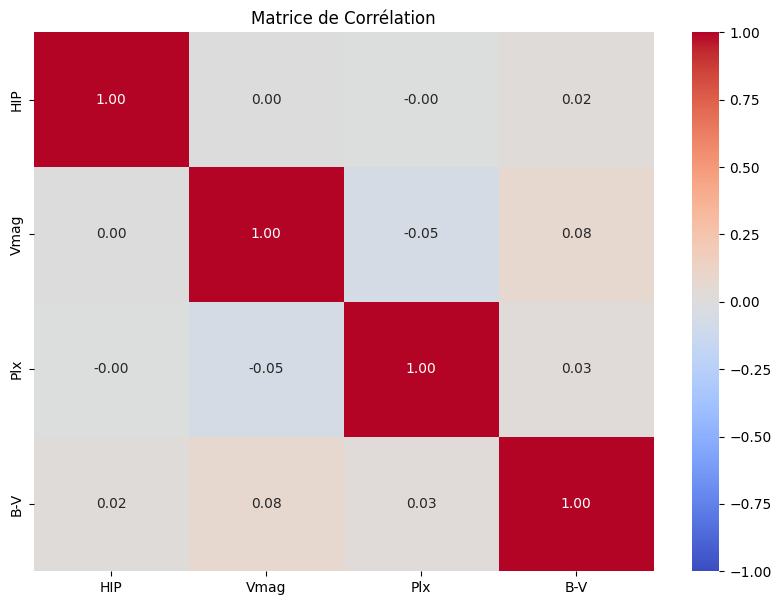

In [5]:
# Extraire quelques données qui semblent être pertinentes (pour une meilleure visualisation)

def matrice_corr(sub_data_name, data) :
    num_data = data.select_dtypes(include=['number'])
    sub_data = num_data[sub_data_name]
    corr_matrix_sub = sub_data.corr()
    print(corr_matrix_sub)

    plt.figure(figsize=(10, 7))
    sns.heatmap(corr_matrix_sub, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
    plt.title("Matrice de Corrélation")
    plt.show()

matrice_corr(['HIP', 'Vmag', 'Plx', 'B-V'], data_true)  



In [6]:
data_sub = data_true[['HIP', 'Vmag', 'Plx', 'B-V']]
#sns.pairplot(data=data_sub)  

### 2.4 - Sélection et créations de variables d'entrainement pertinentes 


In [7]:
# Sélection des variables pertinentes 
data = data_true[['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']]

# Filtrer les étoiles avec une parallaxe positive 
data = data[data['Plx'] > 0]

# Calcul de la distance (en pc) 
data['Distance'] = 1/data['Plx'] * 1000  

# Calcul de la magnitude absolue 
data['AbsoluteMag'] = data['Vmag'] - 5 * np.log10(data['Distance'] / 10)   

# Fonction pour calculer la température effective des étoiles
def bv_to_temp(bv):
    return 4600 * ((1 / (0.92 * bv + 1.7)) + (1 / (0.92 * bv + 0.62)))

# Ajouter la température aux données
data['Temperature'] = bv_to_temp(data['B-V'])


Le type spectral est une variable catégorielle qui doit être convertie en une forme utilisable par un algorithme de clustering : 
(O, B, A, F, G, K, M) ---> (1, 2, 3, ...)

In [8]:
# Encodage du type spectral
encoder = LabelEncoder()
data['SpType_encoded'] = encoder.fit_transform(data['SpType'])

# Supression du type spectral 
data = data.drop(columns=['SpType'])

### 2.3 - Traitement des données manquantes

In [9]:
# Vérfifier les valeurs manquantes 
missing_data = data.isnull()
nb_missing_value = missing_data.sum()    # Nombre de valeurs manquantes par colonne
print(nb_missing_value)


HIP                 0
Vmag                0
Plx                 0
B-V               887
Distance            0
AbsoluteMag         0
Temperature       887
SpType_encoded      0
dtype: int64


In [10]:
# Afficher le pourcentage de valeurs manquantes
missing_percent = missing_data.mean() * 100
print(missing_percent)

HIP               0.000000
Vmag              0.000000
Plx               0.000000
B-V               0.780055
Distance          0.000000
AbsoluteMag       0.000000
Temperature       0.780055
SpType_encoded    0.000000
dtype: float64


In [11]:
# Heatmap des valeurs manquantes
#plt.figure(figsize=(10, 6))
#sns.heatmap(data.isnull(), cmap="viridis")
#plt.title("Visualisation des valeurs manquantes")
#plt.show()

In [12]:
# Traiter les valeurs manquantes : comme on a énormément de données, on peut supprimer les lignes avec les valeurs manquantes dans les colonnes pertinentes 
data_clean = data.dropna(subset=['HIP', 'Vmag', 'Plx', 'B-V', 'Distance', 'AbsoluteMag', 'Temperature', 'SpType_encoded'])
print(data_clean.shape)


(112823, 8)

In [13]:
data_clean

,HIP,Vmag,Plx,B-V,Distance,AbsoluteMag,Temperature,SpType_encoded
0,1,9.10,3.54,0.482,282.485876,1.845016,6471.667826,1809
1,2,9.27,21.90,0.999,45.662100,5.972221,4745.140425,3178
2,3,6.61,2.81,-0.019,355.871886,-1.146468,10368.595588,1353
3,4,8.06,7.75,0.370,129.032258,2.506509,7044.130880,1604
4,5,8.55,2.87,0.902,348.432056,0.839409,4991.060700,2649
...,...,...,...,...,...,...,...,...
118213,118318,6.99,1.92,1.595,520.833333,-1.593494,3655.993639,3015
118214,118319,8.23,10.63,0.639,94.073377,3.362666,5818.920292,2296
118215,118320,7.59,5.00,0.999,200.000000,1.084850,4745.140425,2768
118216,118321,9.20,19.22,0.698,52.029136,5.618767,5608.544902,2470


### 2.5 - Vérification de nouvelles variables 


                Distance  AbsoluteMag  Temperature  SpType_encoded       B-V
Distance        1.000000     -0.33716    -0.003166        0.015183  0.034706
AbsoluteMag    -0.337160      1.00000    -0.112810        0.120800 -0.054170
Temperature    -0.003166     -0.11281     1.000000       -0.806002 -0.930123
SpType_encoded  0.015183      0.12080    -0.806002        1.000000  0.826801
B-V             0.034706     -0.05417    -0.930123        0.826801  1.000000


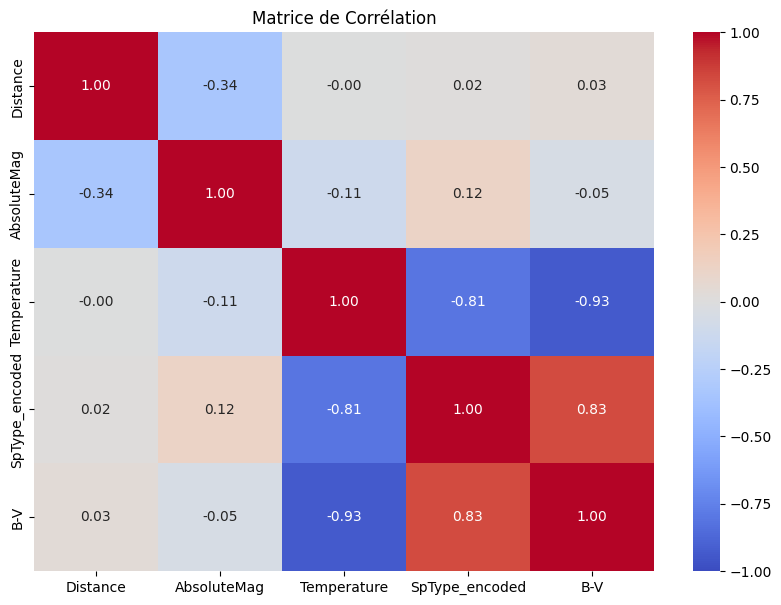

In [14]:
matrice_corr(['Distance', 'AbsoluteMag', 'Temperature', 'SpType_encoded', 'B-V'], data)

/var/folders/dg/n9_jcfbj2bxbp7rjjcdpggn40000gn/T/ipykernel_7615/2070644038.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean.loc[:, 'Type_Étoile'] = data_clean.apply(labelliser_etoile, axis=1)


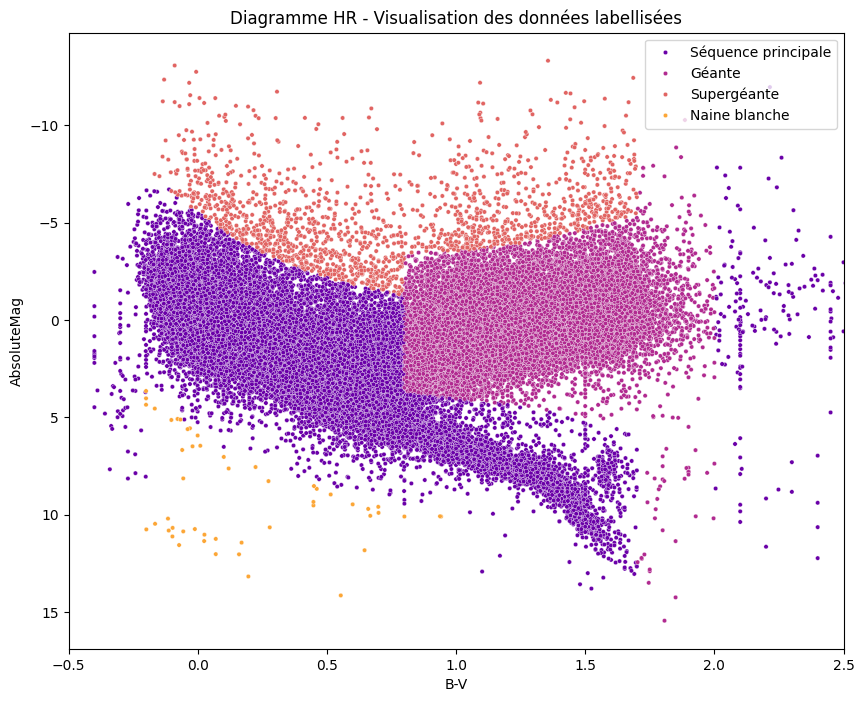

In [15]:
def mag_seq_princ(bv):
    return 4.95 * bv**3 - 12.07 * bv**2 + 13.91 * bv

def mag_geantes(bv):
    return -2.1 * bv**2.2 + 2.9 * bv + 0.5

def mag_supergiantes(bv):
    return -6 * np.exp(-bv) - 1.2 * bv**2 - 5

def mag_naines_blanches(bv):
    return -2.1 * (bv + 0.5)**2 + 5.9 * (bv + 0.5) + 9

bv_seq_princ = np.linspace(-0.2, 1.7, 100)
bv_geantes = np.linspace(0.8, 1.7, 100) 
bv_superg = np.linspace(-0.2, 1.7, 100) 
bv_naine_blanche = np.linspace(-0.2, 1.0, 100)

abs_mag_seq_princ = mag_seq_princ(bv_seq_princ)
abs_mag_geantes = mag_geantes(bv_geantes)
abs_mag_superg = mag_supergiantes(bv_superg)
abs_mag_naine_blanche = mag_naines_blanches(bv_naine_blanche)

def labelliser_etoile(row):
    bv = row['B-V']
    mag = row['AbsoluteMag']
    
    if np.isnan(bv) or np.isnan(mag):
        return np.nan

    distances = {}

    if -0.2 <= bv <= 1.7:
        distances['Séquence principale'] = abs(mag - mag_seq_princ(bv))
    else:
        distances['Séquence principale'] = np.inf

    if 0.8 <= bv <= 2.0:
        distances['Géante'] = abs(mag - mag_geantes(bv))
    else:
        distances['Géante'] = np.inf

    if -0.2 <= bv <= 1.7:
        distances['Supergéante'] = abs(mag - mag_supergiantes(bv))
    else:
        distances['Supergéante'] = np.inf

    if -0.2 <= bv <= 1.0:
        distances['Naine blanche'] = abs(mag - mag_naines_blanches(bv))
    else:
        distances['Naine blanche'] = np.inf

    return min(distances, key=distances.get)



data_clean.loc[:, 'Type_Étoile'] = data_clean.apply(labelliser_etoile, axis=1)



plt.figure(figsize=(10, 8))
sns.scatterplot(data=data_clean, x='B-V', y='AbsoluteMag', hue='Type_Étoile', palette='plasma', s= 10)
plt.gca().invert_yaxis()
plt.xlim(-0.5, 2.5)
plt.title("Diagramme HR - Visualisation des données labellisées")
plt.legend()
plt.show()

### 2.6 - Normalisation des variables d'entrainement 

Plusieurs méthodes existent pour normaliser les données.

In [17]:
X_to_scale = data_clean.iloc[:, :-1]
# Separar la última columna
X_last_column = data_clean.iloc[:, -1]
# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_to_scale)

# Convertir a DataFrame con nombres de columnas
X_scaled_df = pd.DataFrame(X_scaled, columns=X_to_scale.columns, index=data_clean.index)

# Si quieres volver a unir la última columna:
X_final = pd.concat([X_scaled_df, X_last_column], axis=1)
X_final.head()

,HIP,Vmag,Plx,B-V,Distance,AbsoluteMag,Temperature,SpType_encoded,Type_Étoile
0,-1.727453,0.618564,-0.352599,-0.454175,-0.073805,0.074351,0.130850,-0.227177,Séquence principale
1,-1.727424,0.751857,1.280499,0.615606,-0.176107,1.801635,-0.713214,1.115105,Séquence principale
2,-1.727394,-1.333777,-0.417532,-1.490848,-0.042104,-1.177621,2.035976,-0.674277,Séquence principale
3,-1.727365,-0.196871,0.021875,-0.685926,-0.140093,0.351193,0.410715,-0.428176,Séquence principale
4,-1.727336,0.187324,-0.412195,0.414893,-0.045318,-0.346508,-0.592988,0.596429,Géante


In [37]:
X = X_final.iloc[:, :-1].values
y = X_final.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) 

X_train = pd.DataFrame(X_train, columns = X_final.columns[:-1])

X_test = pd.DataFrame(X_test, columns = X_final.columns[:-1])

In [38]:
rf = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)

In [39]:
rf.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [40]:
y_pred = rf.predict(X_test)

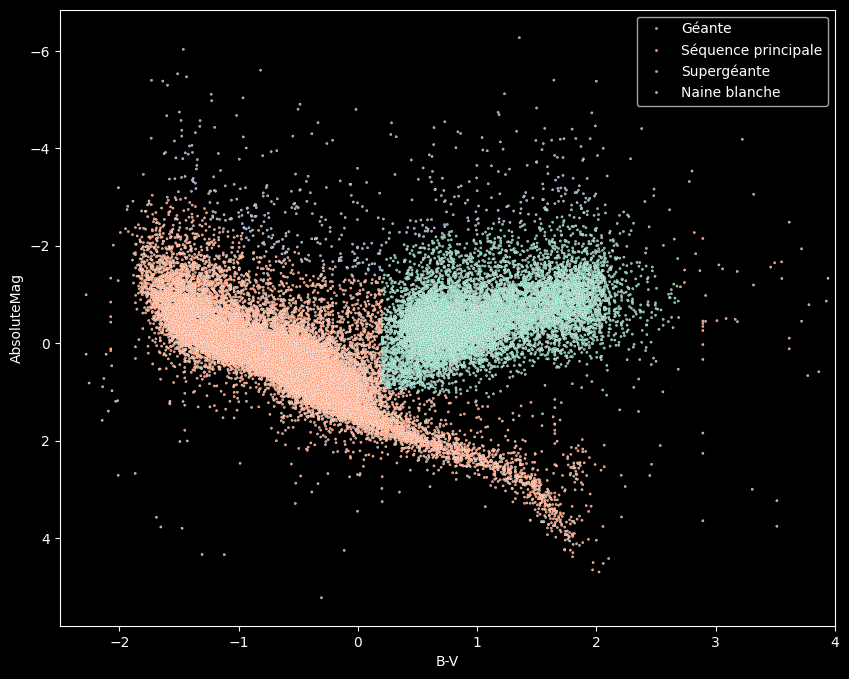

In [46]:
plt.figure(figsize=(10, 8))
#plt.style.use('dark_background')
sns.scatterplot(x=X_test['B-V'], y=X_test['AbsoluteMag'], hue=y_pred, palette='Set2', marker='.', s=10) 
#plt.title("Diagramme HR normalisé sur les données d'entraînement (K-Means)")
plt.gca().invert_yaxis()  # il faut inverser l'axe de AbsoluteMag par convention du diagramme HR
plt.xlim(-2.5, 4)
plt.show()
